In [ ]:
import geopandas as gpd
from pathlib import Path
import os
import numpy as np
from pyproj import Transformer
import requests
import time
import matplotlib.pyplot as plt

# I. Wild Fire Area Analysis

In [ ]:
REPO_ROOT = Path(os.getcwd()).parent
DATA_PATH  = REPO_ROOT / "data" / "backtest" / "hist_data.parquet"

<Axes: ylabel='Frequency'>

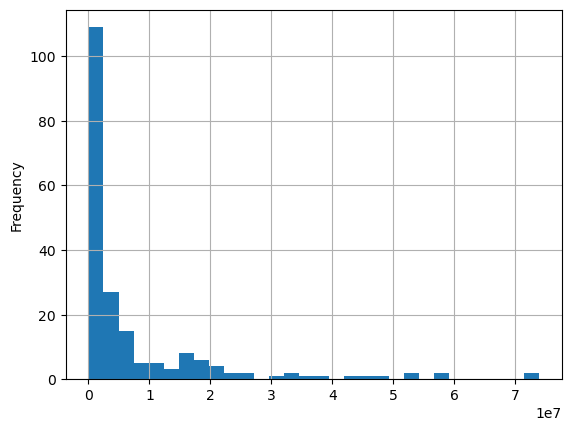

In [8]:
gdf = gpd.read_parquet(DATA_PATH)

gdf_metric = gdf.to_crs(epsg=2154)

areas = gdf_metric.geometry.area

areas.plot.hist(bins= 30, grid = True)

In [9]:
area_data = (gdf.assign(polygon_area = gdf.geometry.area)[["wildfire_id", "prop_step","polygon_area"]]
            .set_index(["wildfire_id", "prop_step"]))

gdf = gdf.merge(area_data, how = 'left', on = ["wildfire_id", "prop_step"])

In [10]:
gdf[["wildfire_id", 'prop_step', 'polygon_area']].query("wildfire_id == 45")

,wildfire_id,prop_step,polygon_area
170,45,0,3.136548e+00
171,45,1,5.548240e+06
172,45,2,1.873395e+07
173,45,3,3.326883e+07
174,45,4,3.605958e+07
175,45,5,4.342728e+07
176,45,6,5.850543e+07


In [11]:
gdf["wildfire_id"].value_counts()

wildfire_id
1     7
45    7
6     6
20    5
4     5
7     5
10    5
12    5
17    5
30    5
35    5
44    5
3     4
16    4
15    4
18    4
25    4
26    4
27    4
28    4
31    4
34    4
37    4
41    4
42    4
50    4
51    4
2     3
5     3
8     3
9     3
11    3
13    3
14    3
19    3
21    3
22    3
23    3
24    3
29    3
32    3
33    3
36    3
38    3
39    3
40    3
43    3
46    3
47    3
48    3
49    3
52    3
Name: count, dtype: int64

In [1]:
%cd ..
from simulators.backtest import FireForestViz, FireForestVizMatrix
%cd notebooks 

/home/perann/Bureau/MVA/Interactions/interactions
/home/perann/Bureau/MVA/Interactions/interactions/notebooks


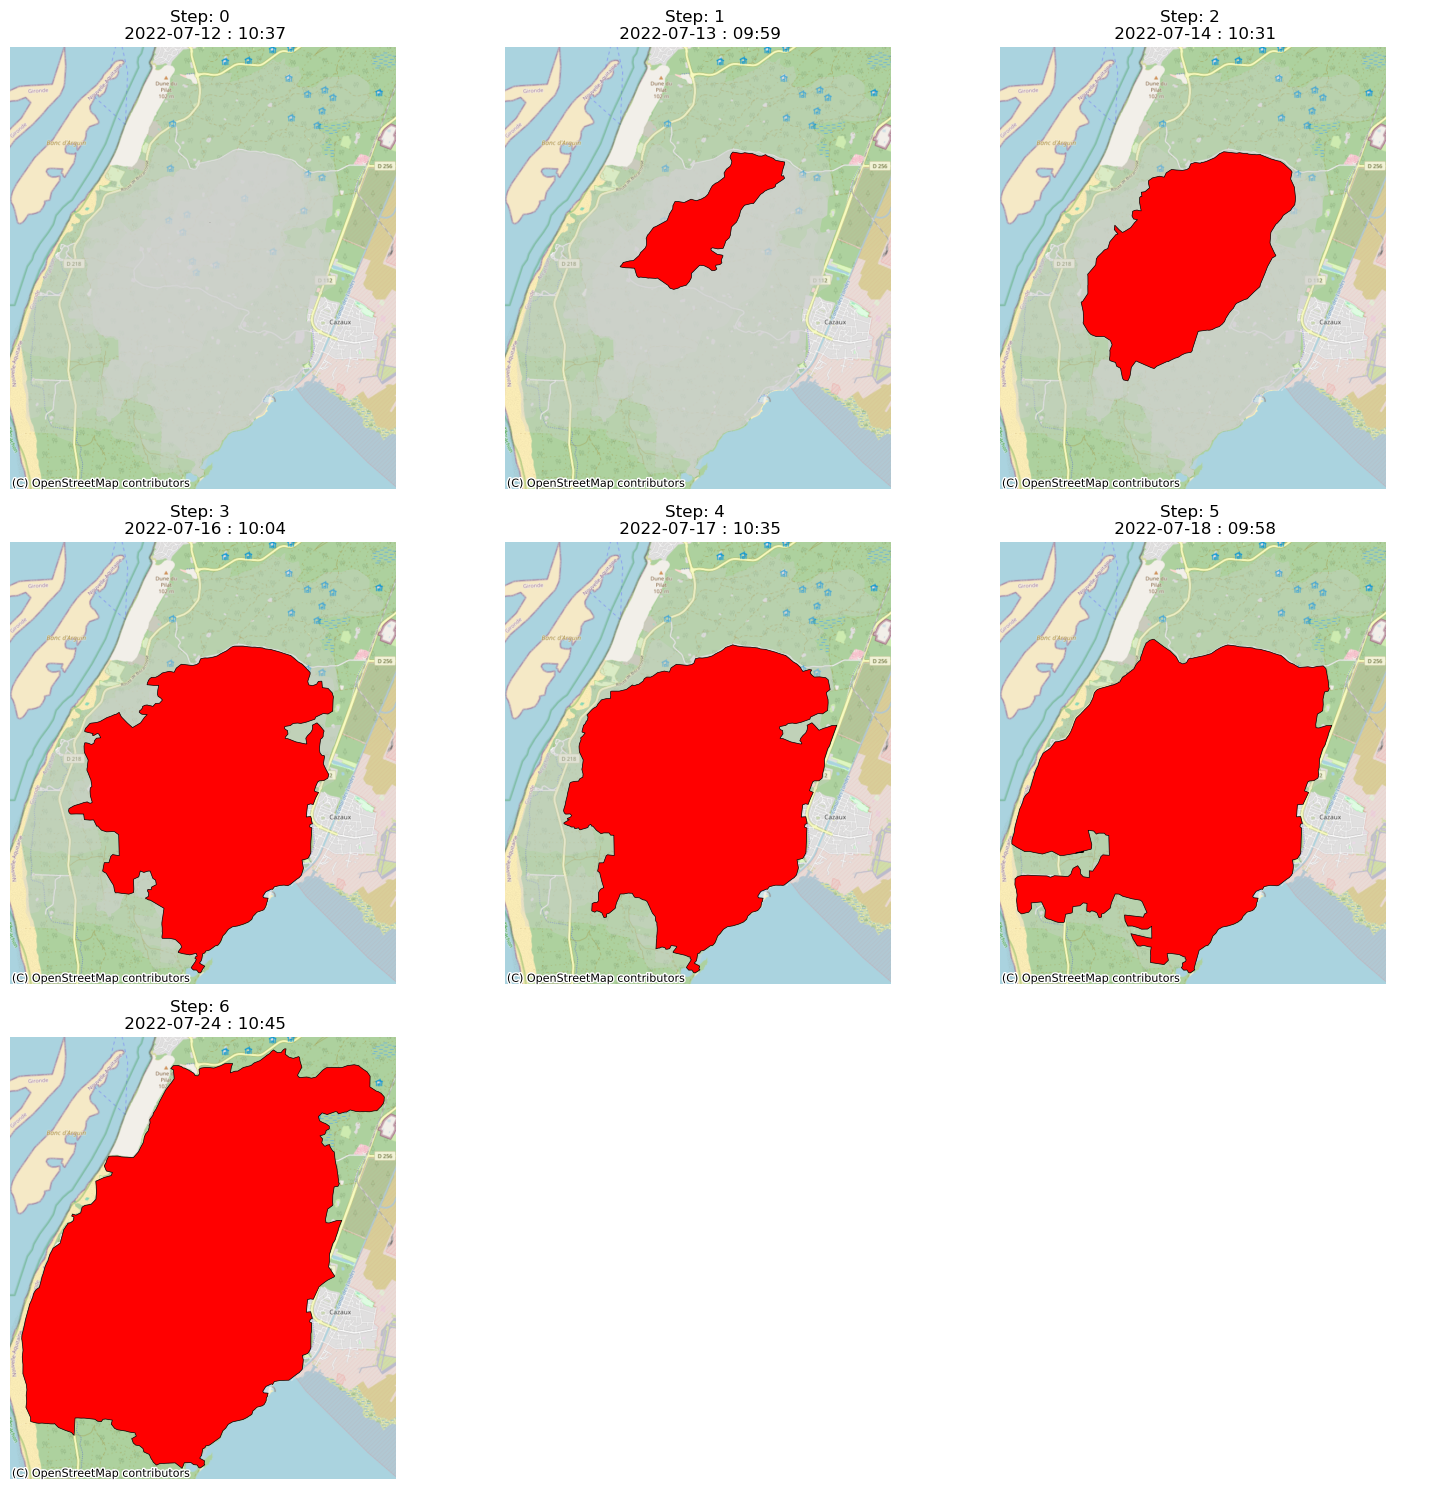

In [2]:
FireForestViz(45)

In [24]:
def generate_covering_grid(wildfire_id : int, margin : int, resolution : int):
    
    minx = gdf[gdf.wildfire_id == wildfire_id].total_bounds[0] - margin
    miny = gdf[gdf.wildfire_id == wildfire_id].total_bounds[1] - margin
    maxx = gdf[gdf.wildfire_id == wildfire_id].total_bounds[2] + margin
    maxy = gdf[gdf.wildfire_id == wildfire_id].total_bounds[3] + margin

    width = int((maxx - minx) / resolution)
    height = int((maxy - miny) / resolution)

    x_centers = minx + (np.arange(width) * resolution) + (resolution / 2)
    y_centers = miny + (np.arange(height) * resolution) + (resolution / 2)

    grid_x, grid_y = np.meshgrid(x_centers, y_centers)

    return grid_x, grid_y

In [25]:
grid_x, grid_y = generate_covering_grid(45, 400, 200)

# II. Getting Weather data

In [21]:
def get_weather_grid(lat_flat, lon_flat, height, width, date_str, hour_idx=10):
    temps = []
    wind_speeds = []
    wind_dirs = []
    chunk_size = 50 
    i = 0
    
    print(f"Récupération météo pour le {date_str} à {hour_idx}h...")

    while i < len(lat_flat):
        lats_chunk = lat_flat[i : i + chunk_size]
        lons_chunk = lon_flat[i : i + chunk_size]
        
        lats_str = ",".join([f"{l:.5f}" for l in lats_chunk])
        lons_str = ",".join([f"{l:.5f}" for l in lons_chunk])
        
        url = (f"https://archive-api.open-meteo.com/v1/archive?"
               f"latitude={lats_str}&longitude={lons_str}&"
               f"start_date={date_str}&end_date={date_str}&"
               f"hourly=temperature_2m,wind_speed_10m,wind_direction_10m&"
               f"timezone=auto")
        
        try:
            response = requests.get(url)
            data = response.json()
            
            if response.status_code == 200:
                for point_data in data:
                    temps.append(point_data['hourly']['temperature_2m'][hour_idx])
                    wind_speeds.append(point_data['hourly']['wind_speed_10m'][hour_idx])
                    wind_dirs.append(point_data['hourly']['wind_direction_10m'][hour_idx])
                
                i += chunk_size
                print(f"Météo : {len(temps)}/{len(lat_flat)} points.")
                time.sleep(0.5)
                
            elif response.status_code == 429:
                print("Limite API. Pause 62s...")
                time.sleep(62)
            else:
                print(f"Erreur : {data.get('reason')}")
                break
        except Exception as e:
            print(f"Erreur connexion : {e}")
            time.sleep(5)

    res_temps = np.flipud(np.array(temps).reshape((height, width)))
    res_wind_speed = np.flipud(np.array(wind_speeds).reshape((height, width)))
    res_wind_dir = np.flipud(np.array(wind_dirs).reshape((height, width)))
    
    return res_temps, res_wind_speed, res_wind_dir

In [22]:
gdf[gdf.wildfire_id == 45][["date", "prop_step"]]

,date,prop_step
568,2022-07-12 10:37:25,0
569,2022-07-13 09:59:05,1
570,2022-07-14 10:31:49,2
572,2022-07-16 10:04:17,3
573,2022-07-17 10:35:24,4
574,2022-07-18 09:58:39,5
580,2022-07-24 10:45:44,6


In [30]:
BACKTEST_DATA_PATH = REPO_ROOT / "data" / "backtest" / "fire_example_45"
BACKTEST_DATA_PATH.mkdir(parents=True, exist_ok=True)

transformer = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)
lon_flat, lat_flat = transformer.transform(grid_x.flatten(), grid_y.flatten())

height, width = grid_x.shape

dates = gdf[gdf.wildfire_id == 45]["date"].dt.strftime("%Y-%m-%d").unique()

for date in dates[1:]:
    m_temp, m_wind_v, m_wind_d = get_weather_grid(lat_flat, lon_flat, height, width, date, 10)
    
    np.save(BACKTEST_DATA_PATH / f"{date}_temperature.npy", m_temp)
    np.save(BACKTEST_DATA_PATH / f"{date}_wind_val.npy", m_wind_v)
    np.save(BACKTEST_DATA_PATH / f"{date}_wind_direction.npy", m_wind_d)

Récupération météo pour le 2022-07-13 à 10h...
Météo : 50/2916 points.
Météo : 100/2916 points.
Météo : 150/2916 points.


KeyboardInterrupt: 

In [ ]:
def get_humidity_grid(lat_flat, lon_flat, height, width, date_str, hour_idx=10):
    """
    Récupère la grille d'humidité relative (en %) pour une date et une heure données.
    """
    humidities = []
    chunk_size = 50 
    i = 0
    
    print(f"💧 Récupération humidité pour le {date_str} à {hour_idx}h...")

    while i < len(lat_flat):
        lats_chunk = lat_flat[i : i + chunk_size]
        lons_chunk = lon_flat[i : i + chunk_size]
        
        lats_str = ",".join([f"{l:.5f}" for l in lats_chunk])
        lons_str = ",".join([f"{l:.5f}" for l in lons_chunk])
        
        # URL adaptée avec le paramètre relative_humidity_2m
        url = (f"https://archive-api.open-meteo.com/v1/archive?"
               f"latitude={lats_str}&longitude={lons_str}&"
               f"start_date={date_str}&end_date={date_str}&"
               f"hourly=relative_humidity_2m&"
               f"timezone=auto")
        
        try:
            response = requests.get(url)
            
            if response.status_code == 200:
                data = response.json()
                
                # Open-Meteo renvoie une liste si plusieurs coordonnées sont demandées
                if isinstance(data, list):
                    for point_data in data:
                        humidities.append(point_data['hourly']['relative_humidity_2m'][hour_idx])
                else:
                    # Cas où un seul point est renvoyé (si chunk_size=1 par exemple)
                    humidities.append(data['hourly']['relative_humidity_2m'][hour_idx])
                
                i += chunk_size
                print(f"Humidité : {len(humidities)}/{len(lat_flat)} points récupérés.")
                time.sleep(0.5) # Pause légère pour respecter les limites
                
            elif response.status_code == 429:
                print("\n[!] Limite API atteinte. Pause de 62 secondes...")
                time.sleep(62)
            else:
                print(f"Erreur API inattendue : {response.status_code}")
                break
                
        except Exception as e:
            print(f"Erreur de connexion : {e}. Nouvelle tentative dans 5 secondes...")
            time.sleep(5)

    if len(humidities) >= len(lat_flat):
        res_humidity = np.array(humidities[:len(lat_flat)]).reshape((height, width))
        return np.flipud(res_humidity)
    else:
        print("⚠️ Données incomplètes pour l'humidité.")
        return None


matrix_humidity = get_humidity_grid(lat_flat, lon_flat, height, width, "2022-07-12", hour_idx=10)

💧 Récupération humidité pour le 2022-07-12 à 10h...
Humidité : 50/2916 points récupérés.

[!] Limite API atteinte. Pause de 62 secondes...
Humidité : 100/2916 points récupérés.
Humidité : 150/2916 points récupérés.
Humidité : 200/2916 points récupérés.
Humidité : 250/2916 points récupérés.
Humidité : 300/2916 points récupérés.
Humidité : 350/2916 points récupérés.
Humidité : 400/2916 points récupérés.
Humidité : 450/2916 points récupérés.
Humidité : 500/2916 points récupérés.
Humidité : 550/2916 points récupérés.
Humidité : 600/2916 points récupérés.
Humidité : 650/2916 points récupérés.

[!] Limite API atteinte. Pause de 62 secondes...


In [ ]:
np.save(BACKTEST_DATA_PATH / f"{date}_humidity.npy", matrix_humidity)

# III. Getting altitude data

In [222]:
def get_elevation_grid(lat_flat, lon_flat, height, width):
    elevations = []
    chunk_size = 50  
    i = 0
    
    print(f"Début de la récupération : {len(lat_flat)} points à traiter.")

    while i < len(lat_flat):
        lats_chunk = lat_flat[i : i + chunk_size]
        lons_chunk = lon_flat[i : i + chunk_size]
        
        lats_str = ",".join([f"{l:.5f}" for l in lats_chunk])
        lons_str = ",".join([f"{l:.5f}" for l in lons_chunk])
        
        url = f"https://api.open-meteo.com/v1/elevation?latitude={lats_str}&longitude={lons_str}"
        
        try:
            response = requests.get(url)
            data = response.json()
            
            if response.status_code == 200:
                elevations.extend(data['elevation'])
                print(f"Succès : {len(elevations)}/{len(lat_flat)} points récupérés.")
                i += chunk_size
                time.sleep(1) 
                
            elif response.status_code == 429 or (data.get('error') and 'limit exceeded' in data.get('reason', '')):
                print(f"\n[!] Limite API atteinte au point {i}. Pause de 62 secondes...")
                time.sleep(62) 
            else:
                print(f"Erreur API inattendue : {data.get('reason')}")
                break
                
        except Exception as e:
            print(f"Erreur de connexion : {e}. Nouvelle tentative dans 5 secondes...")
            time.sleep(5)

   
    if len(elevations) >= len(lat_flat):
        # On s'assure d'avoir la taille exacte (au cas où le dernier chunk dépasse)
        final_elev = np.array(elevations[:len(lat_flat)]).reshape((height, width))
        # On inverse le sens pour que le haut de la matrice soit le Nord
        return np.flipud(final_elev)
    else:
        return None


matrix_elevation = get_elevation_grid(lat_flat, lon_flat, height, width)
np.save(BACKTEST_DATA_PATH / "altitude.npy", matrix_elevation)

Début de la récupération : 2916 points à traiter.
Succès : 50/2916 points récupérés.
Succès : 100/2916 points récupérés.
Succès : 150/2916 points récupérés.
Succès : 200/2916 points récupérés.
Succès : 250/2916 points récupérés.
Succès : 300/2916 points récupérés.
Succès : 350/2916 points récupérés.
Succès : 400/2916 points récupérés.
Succès : 450/2916 points récupérés.
Succès : 500/2916 points récupérés.
Succès : 550/2916 points récupérés.
Succès : 600/2916 points récupérés.

[!] Limite API atteinte au point 600. Pause de 62 secondes...
Succès : 650/2916 points récupérés.
Succès : 700/2916 points récupérés.
Succès : 750/2916 points récupérés.
Succès : 800/2916 points récupérés.
Succès : 850/2916 points récupérés.
Succès : 900/2916 points récupérés.
Succès : 950/2916 points récupérés.
Succès : 1000/2916 points récupérés.
Succès : 1050/2916 points récupérés.
Succès : 1100/2916 points récupérés.
Succès : 1150/2916 points récupérés.
Succès : 1200/2916 points récupérés.

[!] Limite API att

FileNotFoundError: [Errno 2] No such file or directory: '/home/perann/Bureau/MVA/Interactions/interactions/data/backtest/fire_example/altitude.npy'

## IV. Testing Cellular automaton

In [14]:
from simulators.CellularAutomaton import CellularAutomaton

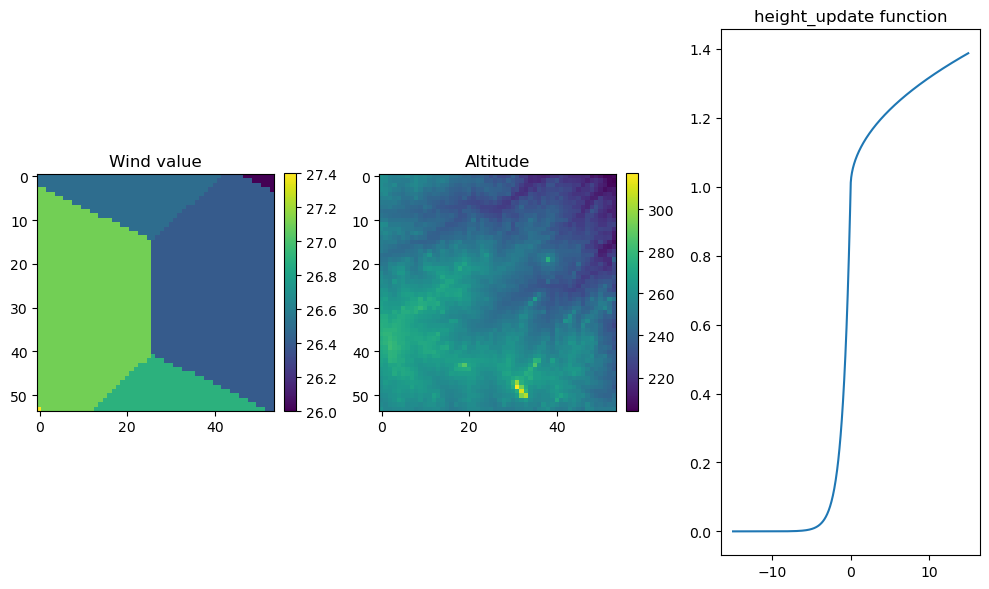

In [31]:
grid_x, grid_y = generate_covering_grid(45, 400, 200)
height, width = grid_x.shape

wind_grid = np.load(BACKTEST_DATA_PATH / "2022-07-12_wind_val.npy")
altitude = np.load(BACKTEST_DATA_PATH /"altitude.npy")

def height_update(x):
        if x <= 0:
            return np.exp(x)
        else:
            return 1 + np.sqrt(x)/10 
    
    
fig, ax = plt.subplots(1,3, figsize = (10, 6))

im0 = ax[0].imshow(wind_grid, cmap= "viridis")
ax[0].set_title("Wind value")
fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)


im1 = ax[1].imshow(altitude, cmap= "viridis")
ax[1].set_title("Altitude")
fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

x = np.linspace(-15, 15, 1000)
y = [height_update(val) for val in x]
ax[2].plot(x,y)
ax[2].set_title("height_update function")

plt.tight_layout() 
plt.show()


In [32]:
def compute_start_point_coord(wildfire_id: int, margin: int, resolution: int):

    fire_data = gdf[gdf.wildfire_id == wildfire_id]
    total_bounds = fire_data.total_bounds
    minx = total_bounds[0] - margin
    maxy = total_bounds[3] + margin 

    start_geom = fire_data.sort_values('prop_step').iloc[0].geometry.centroid
    start_x, start_y = start_geom.x, start_geom.y


    col_idx = int((start_x - minx) // resolution)
    
    row_idx = int((maxy - start_y) // resolution)

    return row_idx, col_idx

start_row, start_col = compute_start_point_coord(45, 400, 200)

In [33]:
m = np.min(wind_grid)
M = np.max(wind_grid)

scaled_wind = (wind_grid - m)/(M-m) + 1

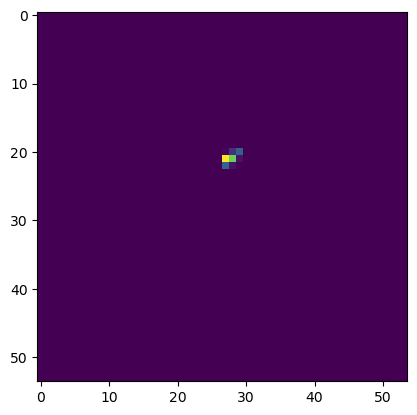

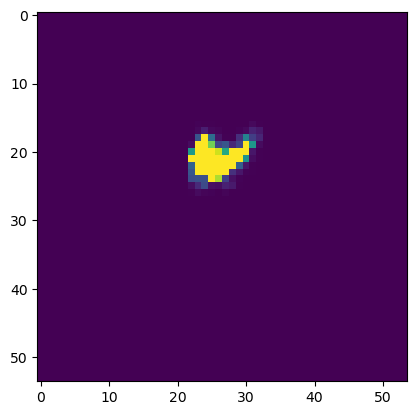

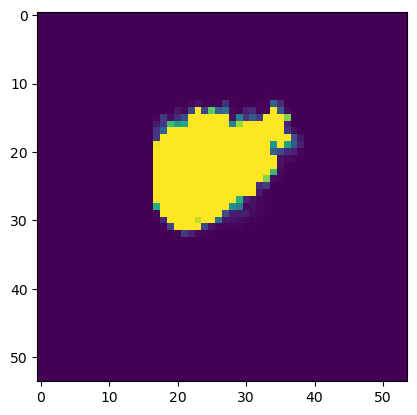

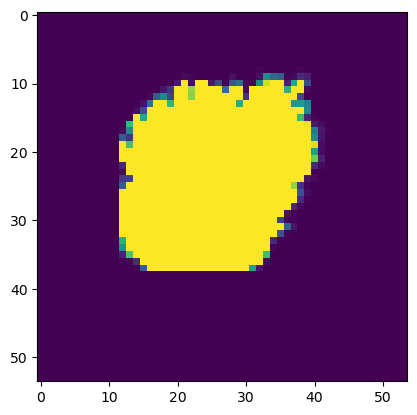

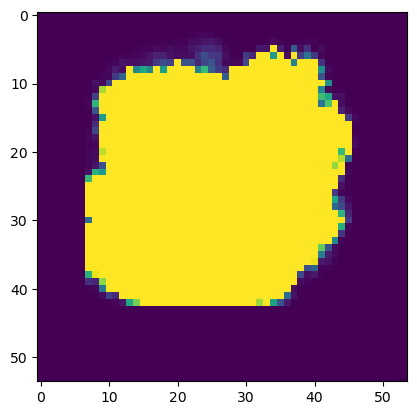

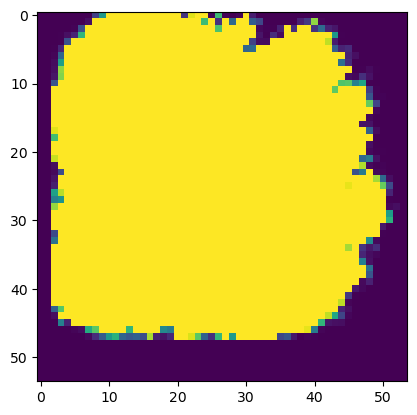

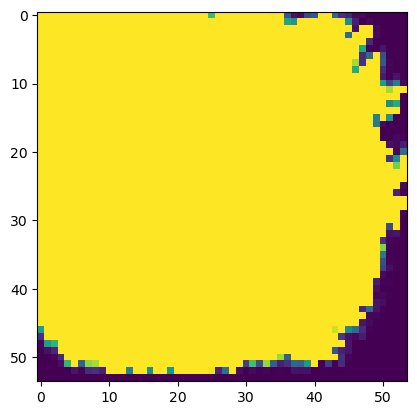

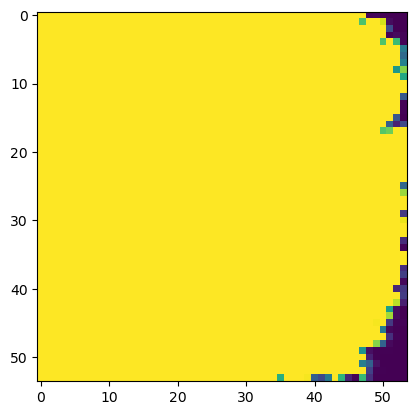

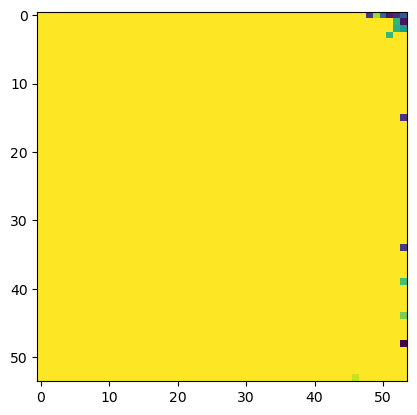

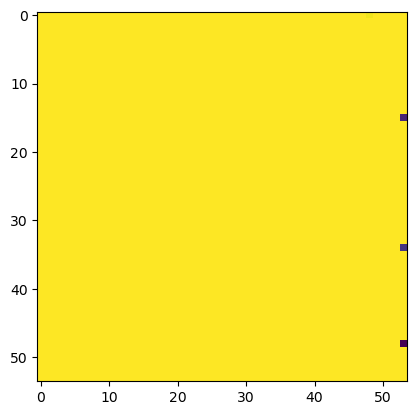

In [36]:
Model = CellularAutomaton(height, width,scaled_wind, altitude, height_update)
Model.initialize_ignition([(start_row, start_col)], [0.01])

current_state = Model.get_state()

for step in range(50):
    Model.evolve()
    if step % 5 == 0:
        current_state = Model.get_state()
        plt.imshow(current_state)
        plt.show()

# V. Translating firepropagation into matrix

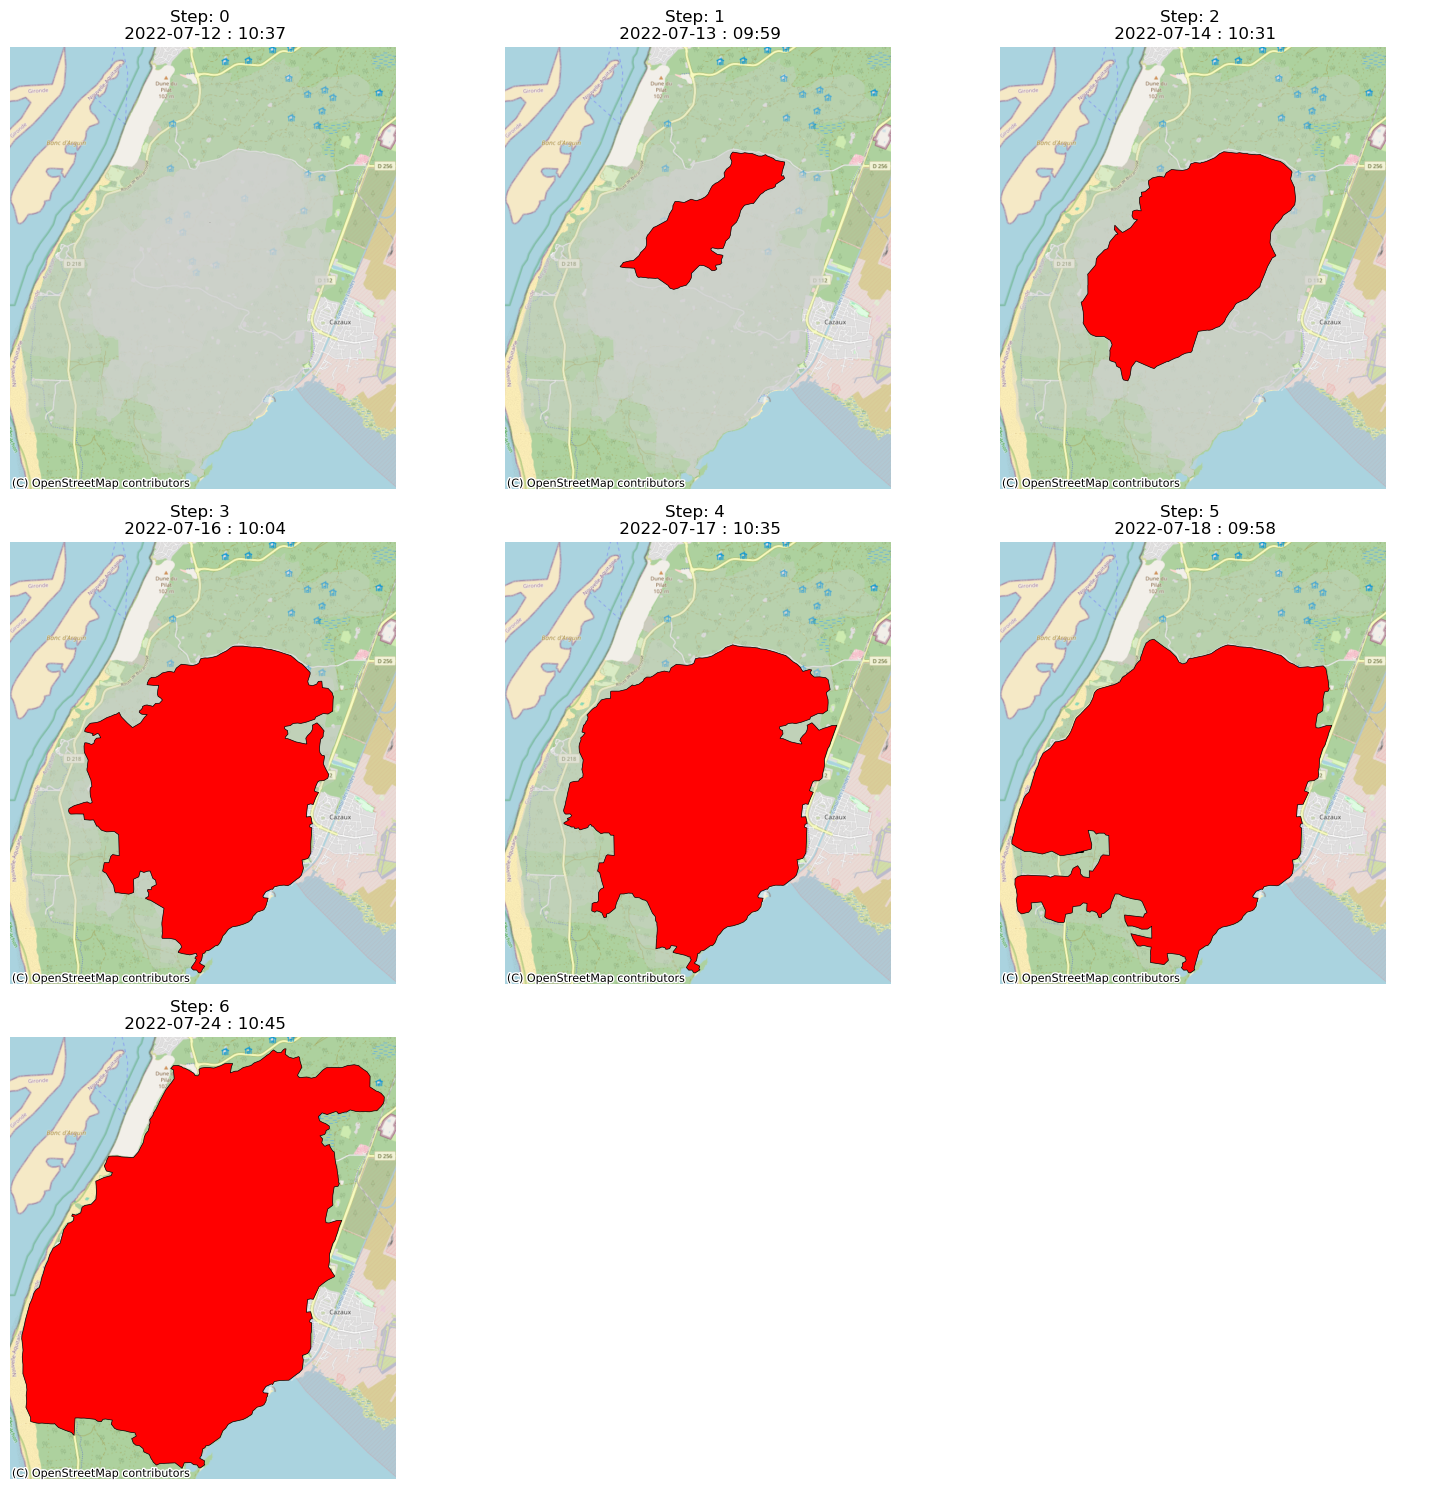

In [3]:
FireForestViz(45)

In [108]:
gdf.columns

Index(['wildfire_id', 'prop_step', 'date', 'country', 'province', 'commune',
       'quality', 'clouds', 'smoke', 'firedate', 'finaldate', 'crop',
       'crop/veg', 'tree-broad', 'tree-needl', 'tree-mixed', 'veg-mixed',
       'shrub', 'sparse_veg', 'urban', 'bare', 'grassland', 'geometry'],
      dtype='str')

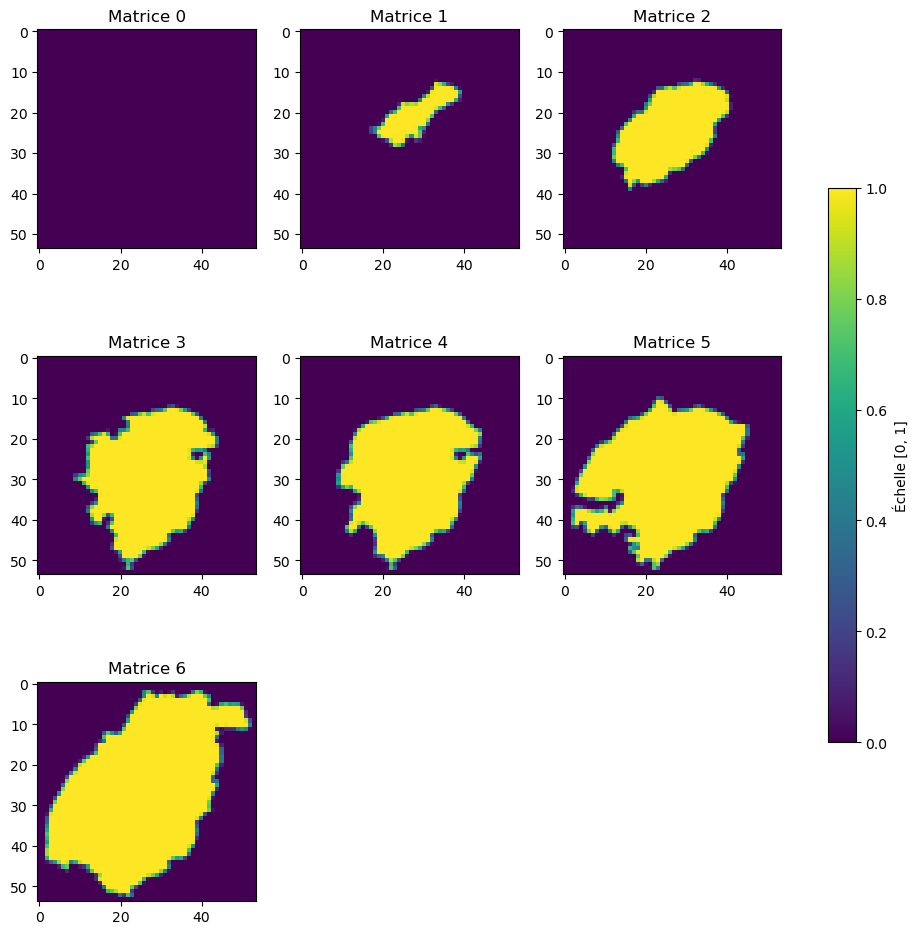

In [9]:
FireForestVizMatrix(45, 400, 200, gdf)

# VI. Metrics computation

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import requests
import pyproj
from shapely.geometry import Point, Polygon, MultiPolygon, LineString
from shapely.prepared import prep
from rasterio import features
from rasterio.transform import from_origin
from scipy.stats import mode

def get_full_composition_grid(fire_id, margin, resolution, gdf_fires):h
    """
    Génère une grille NumPy de composition basée sur les données réelles OSM.
    0: Eau, 1: Urbain, 2: Végétation.
    """
    # 1. Préparation des coordonnées et conversion GPS pour l'API
    fire_row = gdf_fires[gdf_fires.wildfire_id == fire_id]
    bounds = fire_row.total_bounds # [minx, miny, maxx, maxy] en mètres (EPSG:3035 ou 3857)
    
    # Détection automatique du CRS (ou forcage si nécessaire)
    current_crs = gdf_fires.crs if gdf_fires.crs else "EPSG:3857"
    transformer = pyproj.Transformer.from_crs(current_crs, "EPSG:4326", always_xy=True)
    
    # Calcul de la Bounding Box élargie en degrés
    minx, miny, maxx, maxy = bounds[0]-margin, bounds[1]-margin, bounds[2]+margin, bounds[3]+margin
    lon_min, lat_min = transformer.transform(minx, miny)
    lon_max, lat_max = transformer.transform(maxx, maxy)

    # 2. Requête Overpass (Le "Grand Filet")
    # On ratisse large sur les tags pour ne pas rater l'océan ou les bassins
    query = f"""
    [out:json][timeout:90];
    (
      nwr["natural"~"water|wetland|bay|coastline"]({lat_min},{lon_min},{lat_max},{lon_max});
      nwr["waterway"]({lat_min},{lon_min},{lat_max},{lon_max});
      nwr["building"]({lat_min},{lon_min},{lat_max},{lon_max});
      nwr["landuse"~"residential|industrial|commercial|basin|reservoir"]({lat_min},{lon_min},{lat_max},{lon_max});
      nwr["place"~"sea|ocean"]({lat_min},{lon_min},{lat_max},{lon_max});
    );
    out geom;
    """
    
    print(f"📡 Requête OSM sur La Teste-de-Buch (Lat: {lat_min:.2f}, Lon: {lon_min:.2f})...")
    
    try:
        url = "https://overpass-api.de/api/interpreter"
        response = requests.post(url, data={'data': query}, timeout=120)
        data = response.json()
    except:
        print("⚠️ Serveur occupé, tentative sur miroir...")
        response = requests.post("https://overpass.kumi.systems/api/interpreter", data={'data': query})
        data = response.json()

    # 3. Création d'une grille haute résolution pour calculer la majorité (20m)
    fine_res = 20 
    factor = int(resolution / fine_res) # 200/20 = 10
    
    width_fine = int((maxx - minx) / fine_res)
    height_fine = int((maxy - miny) / fine_res)
    fine_grid = np.full((height_fine, width_fine), 2, dtype=np.uint8) # 2 = Végétation

    # Transformation vers tes coordonnées (mètres)
    transform = from_origin(minx, maxy, fine_res, fine_res)

    # 4. Rasterisation (Peinture)
    if 'elements' in data:
        # On prépare les géométries en les reconvertissant en mètres
        to_meters = pyproj.Transformer.from_crs("EPSG:4326", current_crs, always_xy=True)
        
        water_polys = []
        urban_polys = []

        for el in data['elements']:
            if 'geometry' in el:
                # Reconversion des points GPS en mètres
                m_coords = [to_meters.transform(p['lon'], p['lat']) for p in el['geometry']]
                if len(m_coords) < 2: continue
                
                tags = el.get('tags', {})
                # Si c'est fermé -> polygone, sinon -> ligne avec buffer
                if m_coords[0] == m_coords[-1] and len(m_coords) >= 4:
                    geom = Polygon(m_coords)
                else:
                    geom = LineString(m_coords).buffer(20) # Buffer de 20m pour les lignes/côtes

                if any(t in tags for t in ['natural', 'waterway', 'place']) or tags.get('landuse') in ['basin', 'reservoir']:
                    water_polys.append(geom)
                else:
                    urban_polys.append(geom)

        # "Brûlage" sur la grille fine (L'eau écrase l'urbain)
        if urban_polys:
            features.rasterize(urban_polys, out=fine_grid, transform=transform, default_value=1)
        if water_polys:
            features.rasterize(water_polys, out=fine_grid, transform=transform, default_value=0)

    # 5. Agrégation à 200m (Majorité)
    final_h, final_w = height_fine // factor, width_fine // factor
    fine_grid = fine_grid[:final_h*factor, :final_w*factor]
    
    # Reshape pour calculer la stat par bloc de 10x10
    reshaped = fine_grid.reshape(final_h, factor, final_w, factor)
    
    # On calcule le mode (valeur la plus fréquente)
    # Note: On pourrait utiliser np.min si on veut que l'eau (0) gagne dès qu'elle est présente
    final_grid = mode(reshaped, axis=(1, 3), keepdims=False).mode

    print(f"✅ Grille {final_h}x{final_w} générée avec succès.")
    return final_grid

# --- EXEMPLE D'APPEL ---
composition = get_full_composition_grid(fire_id=45, margin=400, resolution=200, gdf_fires=gdf)
# np.save("composition_200m.npy", composition)

📡 Requête OSM sur La Teste-de-Buch (Lat: 44.50, Lon: -1.25)...
⚠️ Serveur occupé, tentative sur miroir...


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

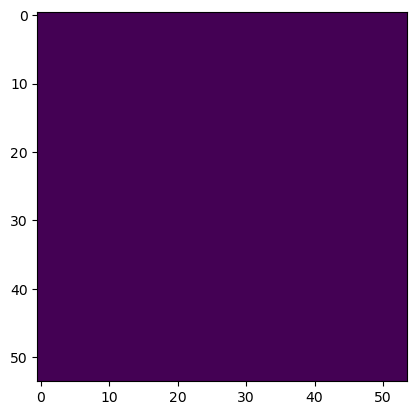

In [ ]:
plt.imshow(composition)